<a href="https://colab.research.google.com/github/abheer2005/Machine-Learning-Projects/blob/main/LoanApprovalPredProj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

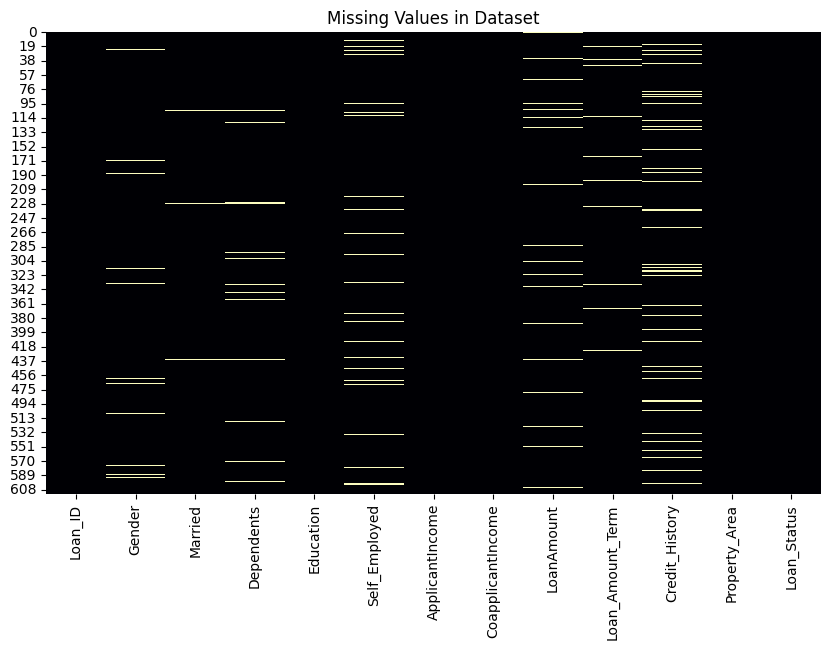

<ipython-input-59-e68b7a2454f1>:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
<ipython-input-59-e68b7a2454f1>:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

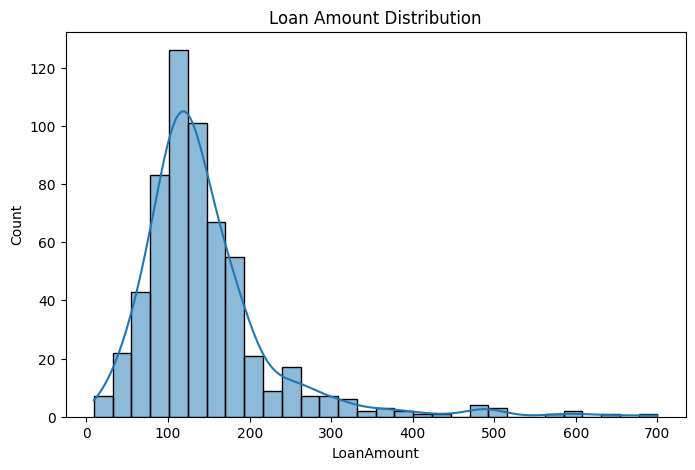

<ipython-input-59-e68b7a2454f1>:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Loan_Status', palette='Set2')


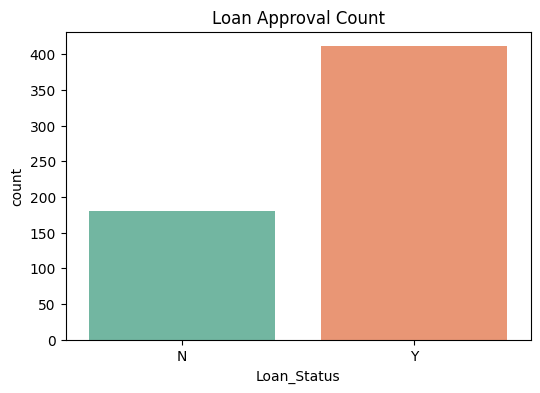

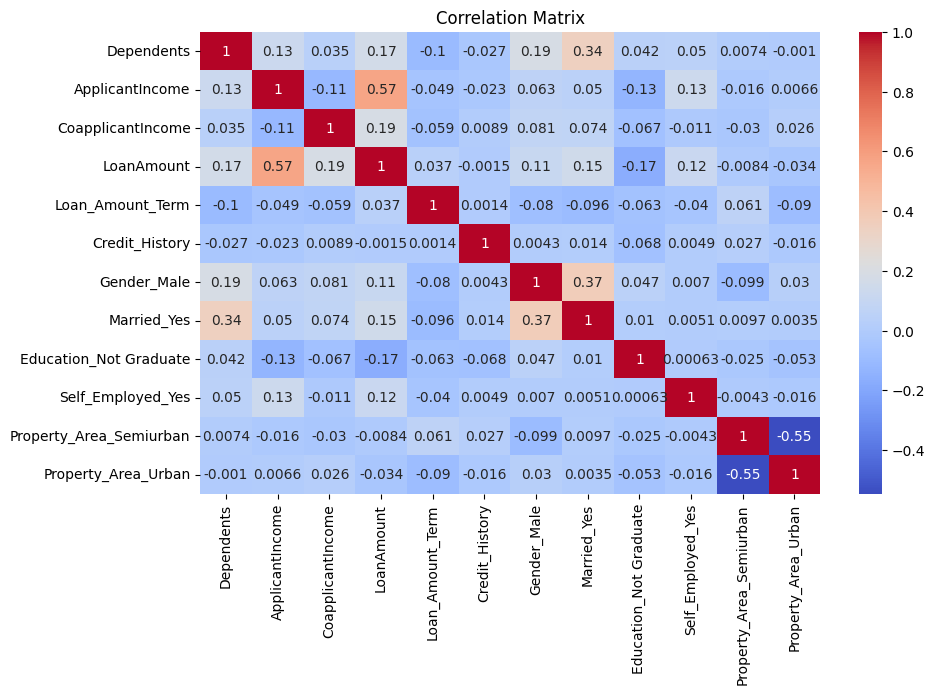

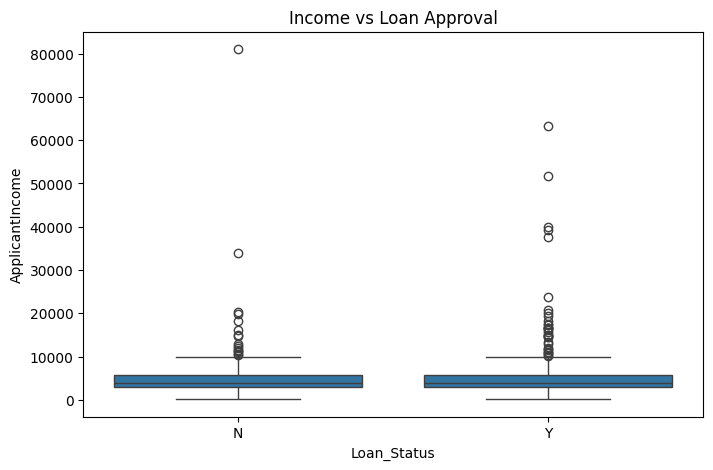

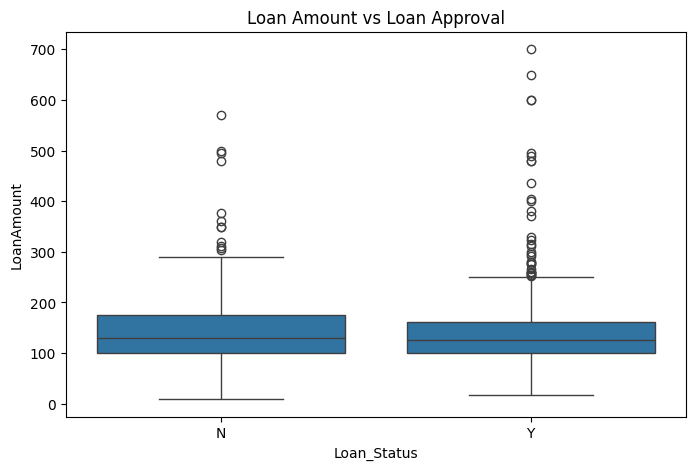

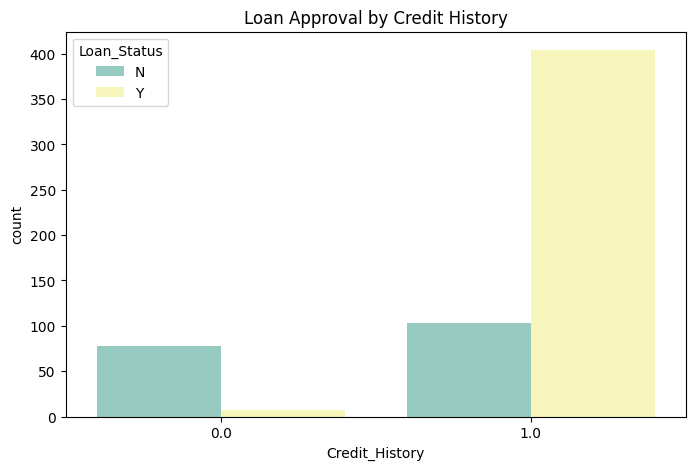

📋 Classification Report:

              precision    recall  f1-score   support

       False       0.72      0.45      0.55        40
        True       0.77      0.91      0.83        79

    accuracy                           0.76       119
   macro avg       0.74      0.68      0.69       119
weighted avg       0.75      0.76      0.74       119

📈 Regression Metrics:
Mean Squared Error: 3.262668067226896
R² Score: 0.9991149397197316


<ipython-input-59-e68b7a2454f1>:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp[:10], y=feat_imp.index[:10], palette="viridis")


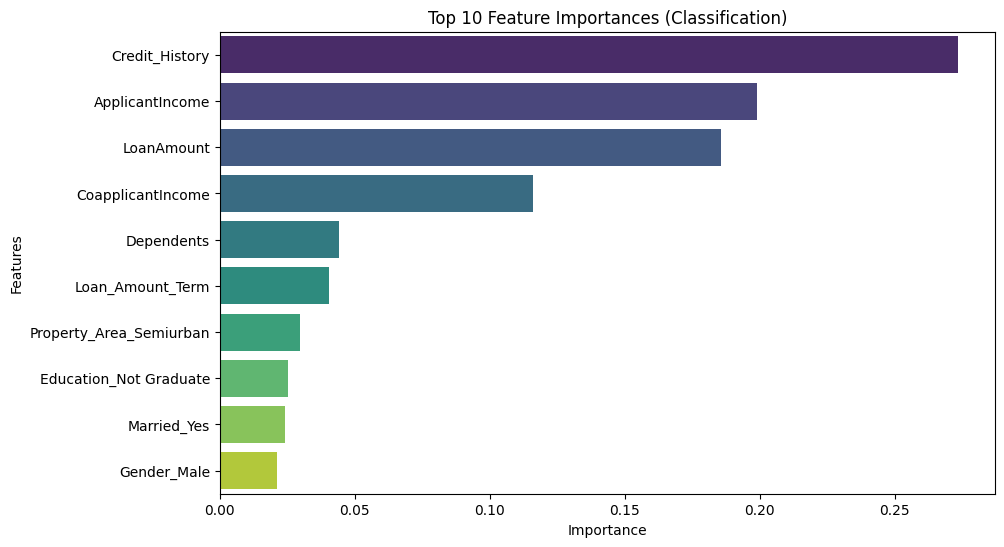

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("loantrain.csv")

# -----------------------------
# 🔍 EDA: Missing Values Heatmap
# -----------------------------
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='magma')
plt.title("Missing Values in Dataset")
plt.show()

# Drop rows with missing target values
df.dropna(subset=['Loan_Status', 'LoanAmount'], inplace=True)

# -----------------------------
# 🧹 Fill missing values
# -----------------------------
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)

# -----------------------------
# 🔍 EDA: Distributions
# -----------------------------
plt.figure(figsize=(8, 5))
sns.histplot(df['LoanAmount'], kde=True, bins=30)
plt.title("Loan Amount Distribution")
plt.xlabel("LoanAmount")
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Loan_Status', palette='Set2')
plt.title("Loan Approval Count")
plt.show()

# -----------------------------
# 🔁 Encode Categorical Variables
# -----------------------------
# Encode categorical columns for both EDA and modeling
# Exclude 'Loan_ID' from encoding as it's just an identifier and not a feature
categorical_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

# Create a copy to avoid modifying the original df before mapping 'Dependents'
df_encoded = df.copy()

# Map 'Dependents' to numeric before get_dummies
# Replace '3+' with '3' so it can be converted to numeric
df_encoded['Dependents'] = df_encoded['Dependents'].replace('3+', '3').astype(int)

# Now apply get_dummies to the rest of the categorical columns and the already numeric Dependents
# Exclude 'Loan_ID' and the already processed 'Dependents' from the get_dummies columns list
cols_for_dummies = [col for col in categorical_cols if col != 'Dependents']

df_encoded = pd.get_dummies(df_encoded.drop('Loan_ID', axis=1), columns=cols_for_dummies, drop_first=True)


# -----------------------------
# 🔍 EDA: Correlation Heatmap
# -----------------------------
# Use df_encoded which already has all relevant categorical columns encoded
# Exclude the target variable Loan_Status_Y from correlation calculation
# The original Loan_ID was already excluded during the creation of df_encoded

# Drop the target column 'Loan_Status_Y' before calculating correlation
# 'Loan_Status_Y' is the target variable, and we want correlation between features
corr_matrix = df_encoded.drop('Loan_Status_Y', axis=1).corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# -----------------------------
# 🔍 EDA: Relationship Plots
# -----------------------------
# Use the original df for these plots as they use the categorical 'Loan_Status' and 'Credit_History'
# before one-hot encoding. Make sure df still has the necessary columns.
# The dropna and fillna steps above ensure these columns exist.
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Loan_Status', y='ApplicantIncome')
plt.title("Income vs Loan Approval")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Loan_Status', y='LoanAmount')
plt.title("Loan Amount vs Loan Approval")
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Credit_History', hue='Loan_Status', palette='Set3')
plt.title("Loan Approval by Credit History")
plt.show()


# -----------------------------
# 🧾 Features and Targets
# -----------------------------
# 'Loan_ID' is already dropped in df_encoded
X = df_encoded.drop('Loan_Status_Y', axis=1)
y_class = df_encoded['Loan_Status_Y']
y_reg = df_encoded['LoanAmount'] # Note: This y_reg comes from the df_encoded where Dependents is numeric

# Split
X_train, X_test, y_class_train, y_class_test = train_test_split(X, y_class, test_size=0.2, random_state=42)
# Split for regression target (LoanAmount), keeping X split the same
# Note: We are using the same X split for both classification and regression,
# as both models use the same set of features to predict their respective targets.
_, _, y_reg_train, y_reg_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)


# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# ✅ Classification Model
# -----------------------------
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_scaled, y_class_train)
y_class_pred = clf.predict(X_test_scaled)

print("📋 Classification Report:\n")
print(classification_report(y_class_test, y_class_pred))

# -----------------------------
# ✅ Regression Model
# -----------------------------
reg = RandomForestRegressor(random_state=42)
reg.fit(X_train_scaled, y_reg_train)
y_reg_pred = reg.predict(X_test_scaled)

print("📈 Regression Metrics:")
print("Mean Squared Error:", mean_squared_error(y_reg_test, y_reg_pred))
print("R² Score:", r2_score(y_reg_test, y_reg_pred))

# -----------------------------
# 🔍 Feature Importance
# -----------------------------
feature_names = X.columns
importances = clf.feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp[:10], y=feat_imp.index[:10], palette="viridis")
plt.title("Top 10 Feature Importances (Classification)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

In [ ]:
def predict_loan_status_amount(new_data_df):
    # 1. Preprocess new_data_df

    # Replace '3+' in Dependents and convert to int
    new_data_df['Dependents'] = new_data_df['Dependents'].replace('3+', '3').astype(int)

    # Encode categorical variables with get_dummies and drop_first=True
    # Use same categorical columns as training (except Loan_Status)
    categorical_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']
    new_data_encoded = pd.get_dummies(new_data_df, columns=categorical_cols, drop_first=True)

    # 2. Align columns with training features (X columns)
    # Missing columns in new_data_encoded (not in training) need to be added with 0
    for col in X.columns:
        if col not in new_data_encoded.columns:
            new_data_encoded[col] = 0

    # Extra columns not in training should be dropped
    new_data_encoded = new_data_encoded[X.columns]

    # 3. Scale features using the trained scaler
    new_data_scaled = scaler.transform(new_data_encoded)

    # 4. Predict
    pred_status = clf.predict(new_data_scaled)
    pred_amount = reg.predict(new_data_scaled)

    # 5. Convert prediction labels back to 'Y'/'N'
    pred_status_labels = ['Y' if val == 1 else 'N' for val in pred_status]

    # 6. Return predictions
    return pred_status_labels, pred_amount


In [ ]:
# Sample input data dictionary (single sample)
sample_data = {
    'Gender': ['Male'],
    'Married': ['Yes'],
    'Dependents': ['1'],
    'Education': ['Graduate'],
    'Self_Employed': ['No'],
    'ApplicantIncome': [50000000],
    'CoapplicantIncome': [900000000],
    'Loan_Amount_Term': [360000000000],
    'Credit_History': [1.0],
    'Property_Area': ['Urban']
}

new_sample_df = pd.DataFrame(sample_data)

pred_status, pred_amount = predict_loan_status_amount(new_sample_df)

print("Predicted Loan Status:", pred_status[0])
print("Predicted Loan Amount:", pred_amount[0])


Predicted Loan Status: N
Predicted Loan Amount: 17.82
